Accuracy: 0.9953360768175583

Classification Report:
               precision    recall  f1-score   support

         cpu       0.89      1.00      0.94        39
  kernel_bug       1.00      1.00      1.00         6
      memory       1.00      1.00      1.00      2102
     network       1.00      0.92      0.96        12
       other       0.99      0.98      0.99       697
    security       1.00      1.00      1.00       748
     storage       0.84      0.90      0.87        41

    accuracy                           1.00      3645
   macro avg       0.96      0.97      0.96      3645
weighted avg       1.00      1.00      1.00      3645



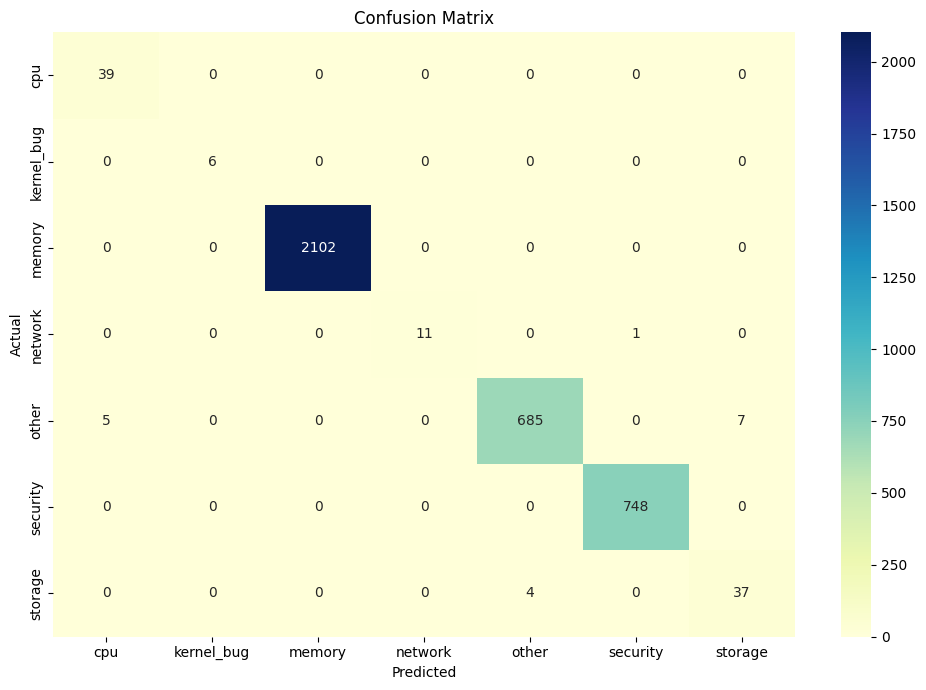

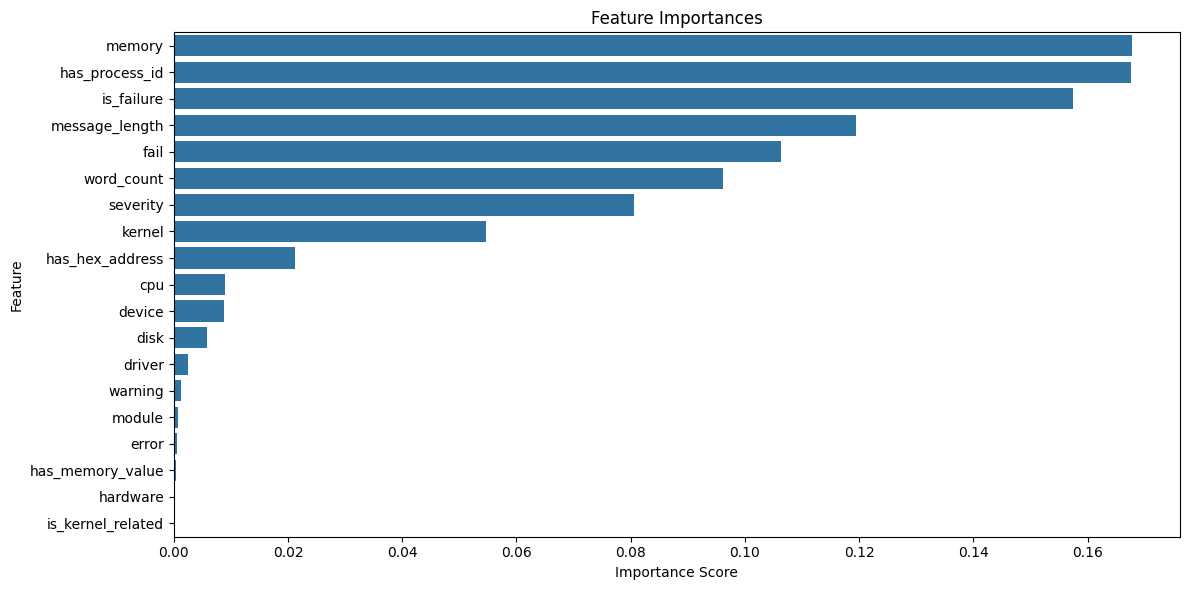

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load data
df = pd.read_csv("processed/linux_kernel_logs.csv")

# Convert categorical target
df['fault_type'] = df['fault_type'].astype('category')
label_mapping = dict(enumerate(df['fault_type'].cat.categories))
df['fault_type'] = df['fault_type'].cat.codes

# Preprocess matched_patterns: convert to one-hot
df['matched_patterns'] = df['matched_patterns'].fillna('none')
pattern_dummies = df['matched_patterns'].str.get_dummies(sep='|')

# Combine with main dataframe
df = pd.concat([df, pattern_dummies], axis=1)

# Drop unused columns
df.drop(columns=['timestamp', 'hostname', 'service', 'message', 'matched_patterns'], inplace=True)

# Split features and labels
X = df.drop(columns=['fault_type'])
y = df['fault_type']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Performance
target_names = [str(label_mapping[i]) for i in sorted(label_mapping.keys())]
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=target_names))

# Confusion Matrix Plot
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu", xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Feature Importance Plot
importances = rf.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
sns.barplot(x=importances[indices], y=feature_names[indices])
plt.title("Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Pairplot (optional, exploratory)
# sns.pairplot(df, hue='fault_type', vars=['severity', 'message_length', 'word_count'])
# plt.suptitle("Pairplot of Selected Features", y=1.02)
# plt.show()


C:\Users\plzzz\AppData\Local\Temp\ipykernel_9192\36340138.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='fault_type', data=df, palette='viridis')


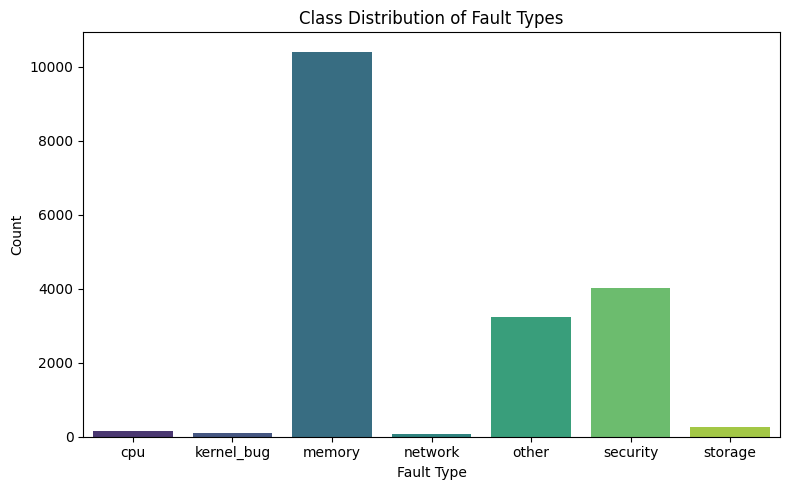

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.countplot(x='fault_type', data=df, palette='viridis')
plt.title("Class Distribution of Fault Types")
plt.xlabel("Fault Type")
plt.ylabel("Count")
plt.xticks(ticks=np.arange(len(label_mapping)), labels=target_names)
plt.tight_layout()
plt.show()


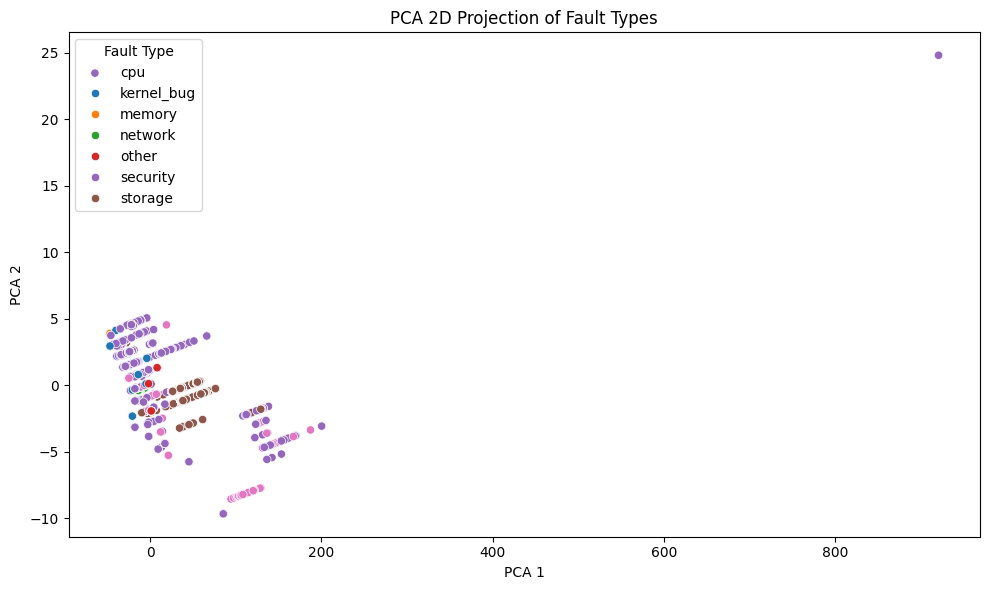

In [6]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='tab10', legend='full')
plt.title("PCA 2D Projection of Fault Types")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Fault Type", labels=target_names)
plt.tight_layout()
plt.show()


In [8]:
misclassified = (y_test != y_pred)

if misclassified.sum() > 0:
    error_df = X_test[misclassified].copy()
    error_df['Actual'] = y_test[misclassified]
    error_df['Predicted'] = y_pred[misclassified]
    
    print("\nSample Misclassifications:\n")
    print(error_df[['Actual', 'Predicted']].head(10).replace(dict(enumerate(target_names))))
else:
    print("No misclassifications found.")
import pandas as pd

# Assuming `y_test` is your actual labels and `y_pred` is your predicted labels
# Let's create a DataFrame to track misclassifications
misclassifications = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

# Find misclassified instances
misclassified_rows = misclassifications[misclassifications['Actual'] != misclassifications['Predicted']]

# Count the misclassifications by actual and predicted fault types
misclassification_counts = misclassified_rows.groupby(['Actual', 'Predicted']).size().reset_index(name='Count')

# Display the counts of misclassifications
print(misclassification_counts)




Sample Misclassifications:

        Actual Predicted
2085     other   storage
16947    other       cpu
88       other       cpu
3165   network  security
2152     other       cpu
3314     other   storage
15818    other       cpu
135    storage     other
17086  storage     other
257      other   storage
   Actual  Predicted  Count
0       3          5      1
1       4          0      5
2       4          6      7
3       6          4      4
